In [1]:
##Import Library
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy import stats 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder,PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
#Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
 
import joblib
 
RANDOM_STATE = 42

**Load datasets**

In [2]:
##Reading the dataset
DATA_FILE_1 = pd.read_csv("Crop Yeild Data.csv")
DATA_FILE_2 = pd.read_csv("Custom_Crops_yield_Historical_Dataset.csv")

**Display the Dataset1**

In [3]:
DATA_FILE_1

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500,20.292,29.860,12.067
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000,20.292,29.860,12.067
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285,-3.143,9.582,-15.017
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.017,-3.143,9.582,-15.017


**Filling the Missing Values(Audit)**

In [4]:
##Checking for the null values
print(DATA_FILE_1.info())
print("\nMissing values:")
print(DATA_FILE_1.isnull().sum())
print("\nDuplicate rows:", DATA_FILE_1.duplicated().sum())
print("\nRegression target statistics:")
print(DATA_FILE_1["Annual_Rainfall"].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
 10  Avg_Temperature  19689 non-null  float64
 11  Max_Temperature  19689 non-null  float64
 12  Min_Temperature  19689 non-null  float64
dtypes: float64(8), int64(2), object(3)
memory usage: 2.0+ MB
None

Missing values:
Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production  

**Dataset 1 EDA for Regression**

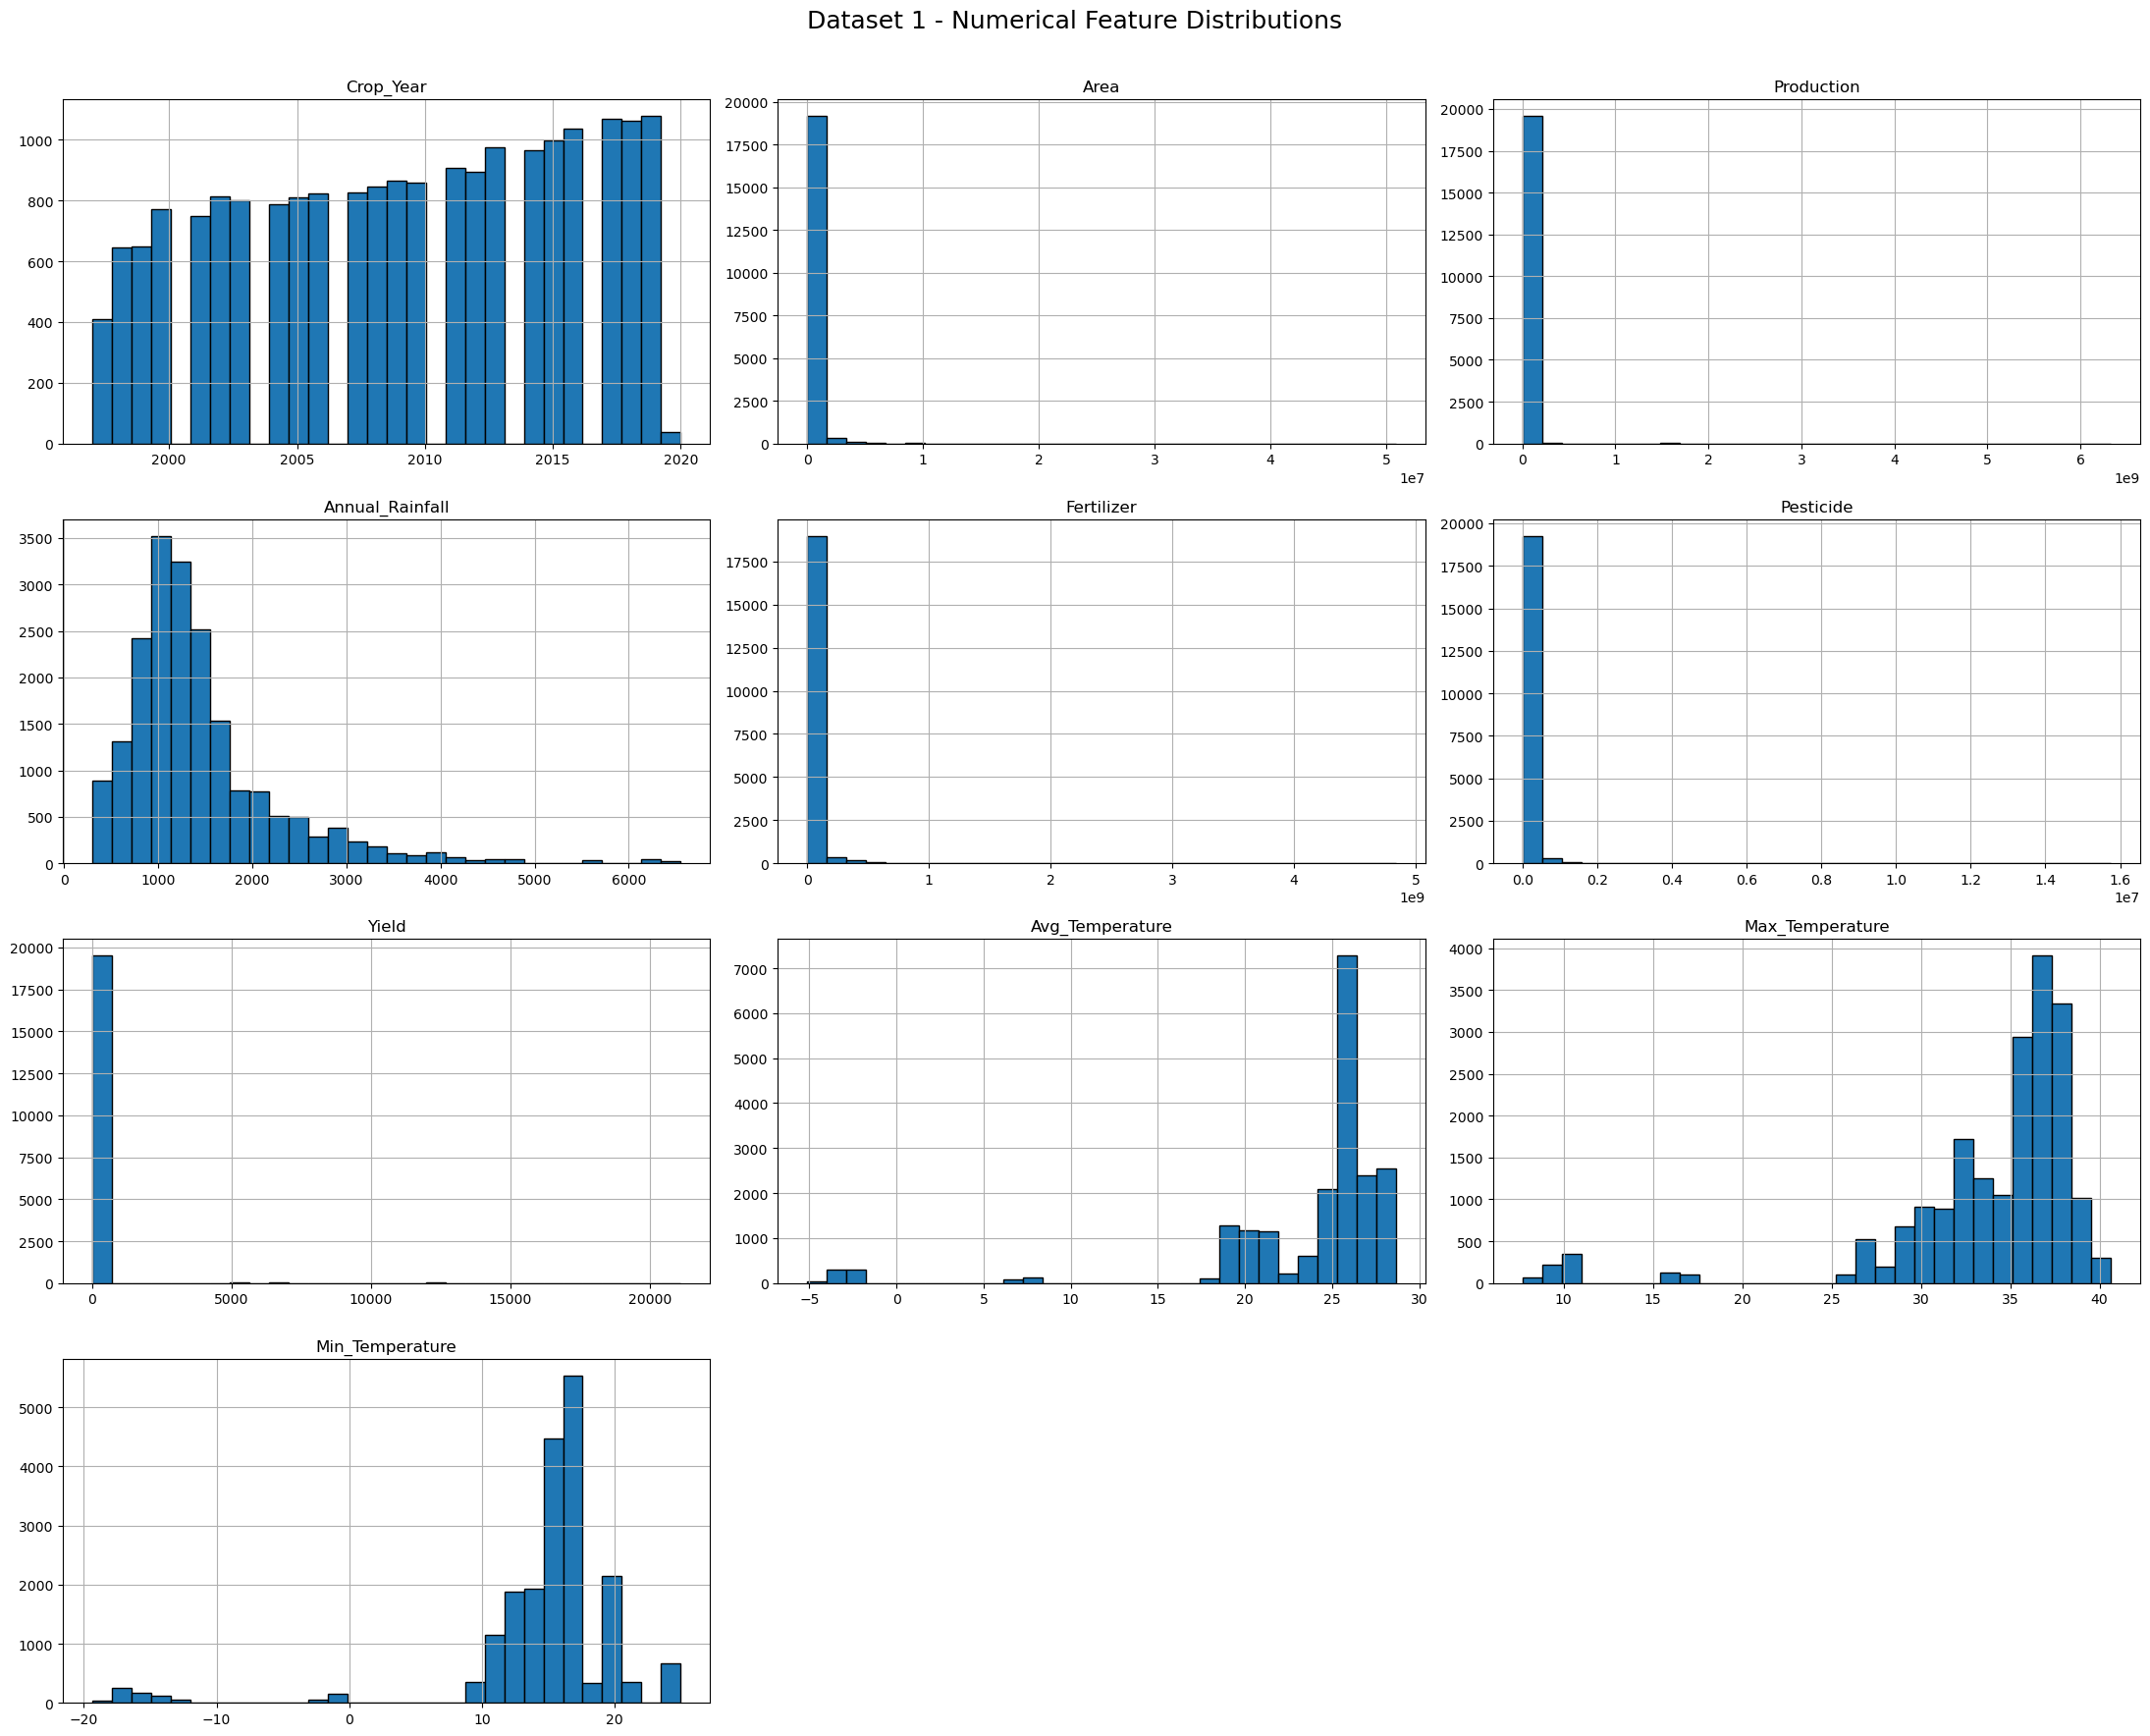

In [5]:
numeric_cols_reg_eda = DATA_FILE_1.select_dtypes(include=np.number).columns.tolist()

DATA_FILE_1[numeric_cols_reg_eda].hist(
    bins=30, figsize=(22, 18), edgecolor="black"
)
plt.suptitle("Dataset 1 - Numerical Feature Distributions", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

**1.Crop Year:**
The observations are distributed across the crop years, with the number of records generally increasing in the later years. This indicates that the dataset contains more observations for recent crop years.

**2. Area:**
The Area distribution is highly right-skewed, with most observations concentrated at relatively small area values. A small number of observations have very large cultivated areas, creating a long right tail.

**3. Production:**
Production is highly right-skewed, with most observations having relatively low production values. A few observations have extremely large production values, indicating the presence of high-value observations or outliers.

**4. Annual Rainfall:**
Annual rainfall is positively skewed, with most observations concentrated at lower-to-moderate rainfall levels. A smaller number of observations have substantially higher rainfall values, producing a long right tail

**5. Fertilizer:**
Fertilizer usage is strongly right-skewed, with most observations concentrated near lower values. A few observations have very high fertilizer usage, indicating considerable variation in fertilizer application.

**6. Pesticide:**
Pesticide usage is also highly right-skewed, with most observations concentrated near smaller values. A small number of records show exceptionally high pesticide usage.

**7. Yield:**
Yield shows a strong right-skewed distribution, where most observations are concentrated at relatively low values. A few observations have very high yields, indicating substantial variation and possible extreme values.

**8. Average Temperature:**
Average temperature values are mainly concentrated between approximately 20°C and 30°C. There are relatively few observations at very low or very high temperatures, showing that most records fall within a moderate temperature range.

**9. Maximum Temperature:**
Maximum temperature is mostly concentrated between approximately 25°C and 35°C. A smaller number of observations occur at lower temperatures, while the majority of values are centered around the higher range.

**10. Minimum Temperature:**
Minimum temperature is mainly concentrated around 10°C–20°C, with most observations falling within this range. A few lower and higher values are present, indicating some variation in minimum temperature.

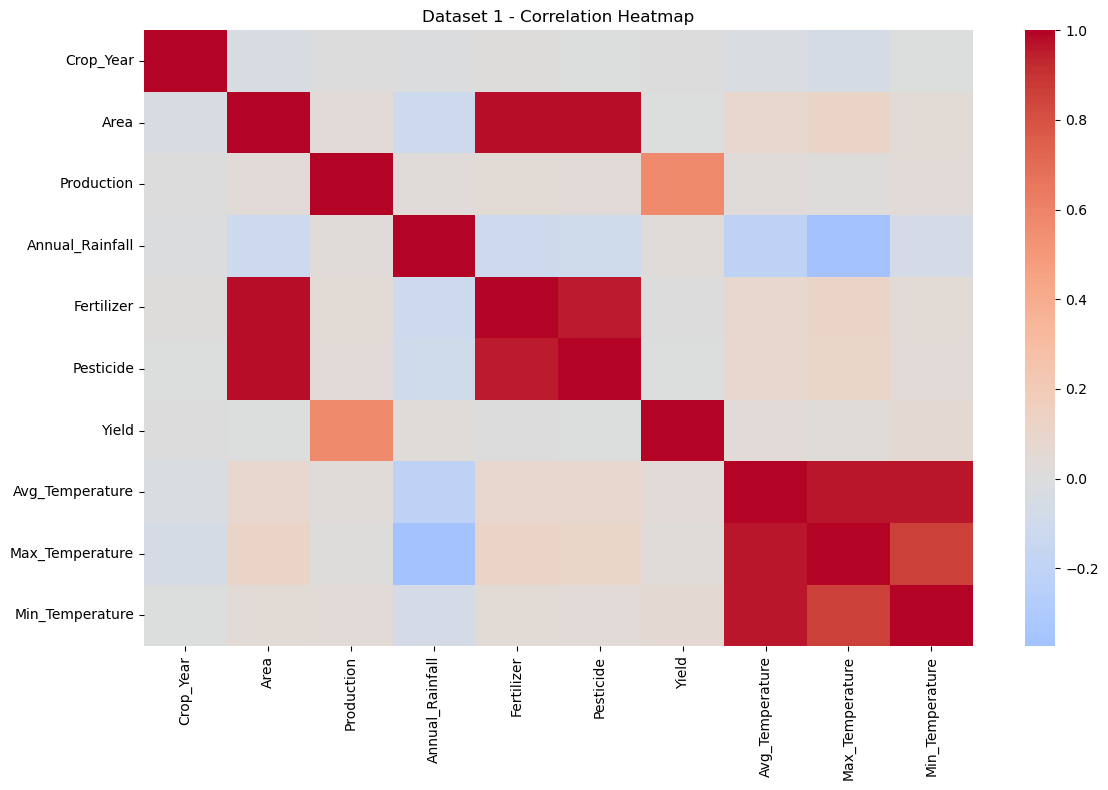

In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(DATA_FILE_1[numeric_cols_reg_eda].corr(), cmap="coolwarm", center=0)
plt.title("Dataset 1 - Correlation Heatmap")
plt.tight_layout()
plt.show()

Strong positive correlations are observed among Area, Fertilizer, Pesticide, and among the three temperature variables. Production and Yield show a moderate positive relationship, while Annual Rainfall has relatively weak negative correlations with temperature-related features.

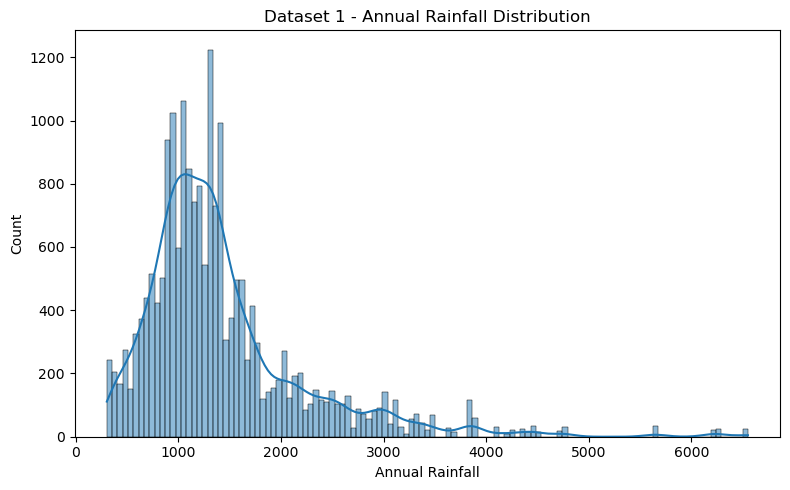

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(DATA_FILE_1["Annual_Rainfall"].dropna(), kde=True)
plt.title("Dataset 1 - Annual Rainfall Distribution")
plt.xlabel("Annual Rainfall")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The distribution of annual rainfall is positively skewed (right-skewed), with most observations concentrated around approximately 700–1,500 mm. A smaller number of observations have much higher rainfall values, extending beyond 6,000 mm, which creates a long right tail and indicates the presence of extreme rainfall observations.

**Dataset 1 feature-target scatter plots**

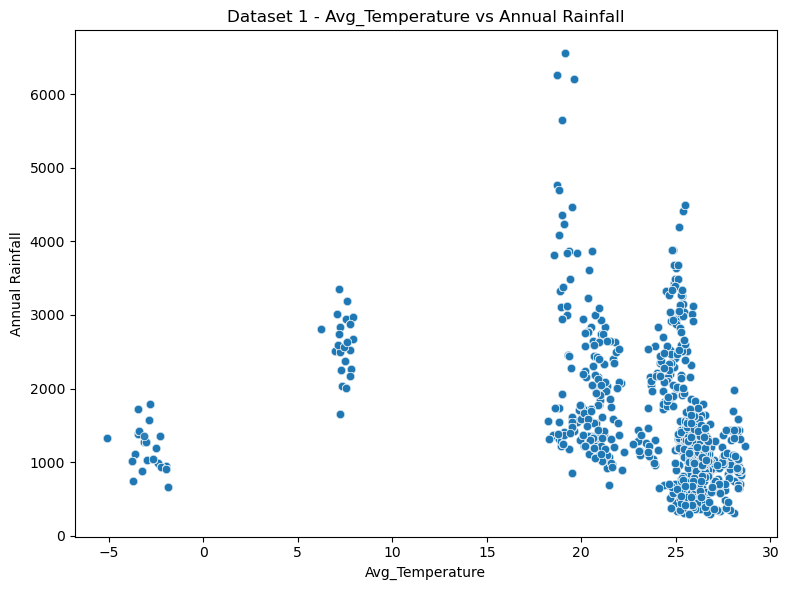

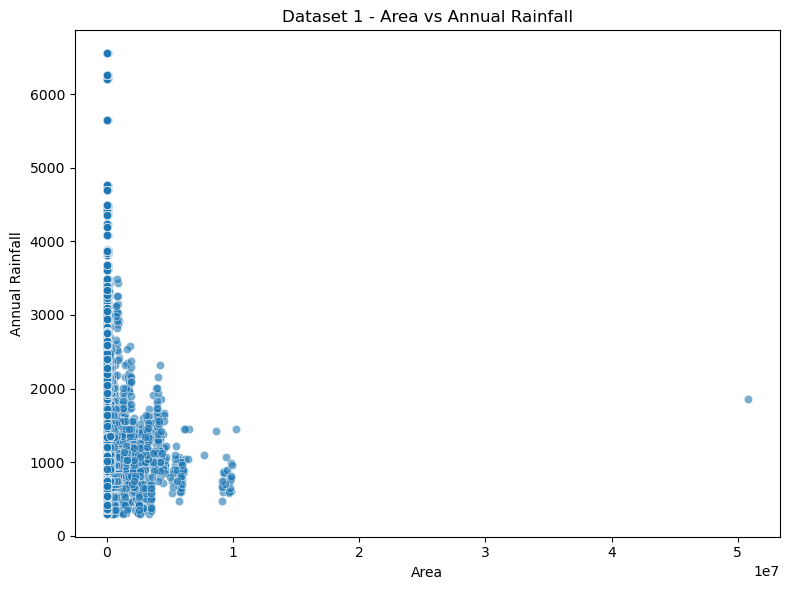

In [8]:
scatter_features = ["Avg_Temperature", "Area"]

for feature in scatter_features:
    if feature in DATA_FILE_1.columns:
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=DATA_FILE_1, x=feature, y="Annual_Rainfall", alpha=0.6)
        plt.title(f"Dataset 1 - {feature} vs Annual Rainfall")
        plt.xlabel(feature)
        plt.ylabel("Annual Rainfall")
        plt.tight_layout()
        plt.show()


**Avg Temperature vs Annual Rainfall:**
The scatter plot shows that annual rainfall varies considerably across different average temperature levels. Most observations are concentrated around 20–27°C, while the highest rainfall values occur mainly around 18–20°C, suggesting that rainfall does not follow a simple linear relationship with average temperature.

**Area vs Annual Rainfall:**
The plot shows that most observations have relatively small area values, while annual rainfall varies widely within this range. A few extremely large area values appear as outliers, and there is no clear linear relationship between area and annual rainfall.

**KEEP: Prepare Dataset 1 for Regression**

In [9]:
# Target = annual_rainfall
# Do not use annual_rainfall or yield as input features because uncertainity in that data.
regression_drop = ["Annual_Rainfall", "yield"]
regression_drop = [c for c in regression_drop if c in DATA_FILE_1.columns]

X_reg = DATA_FILE_1.drop(columns=regression_drop).copy()
y_reg = DATA_FILE_1["Annual_Rainfall"].copy()

# Remove high-cardinality identifiers
id_columns = ["dist_code", "state_code"]
id_columns = [c for c in id_columns if c in X_reg.columns]
X_reg = X_reg.drop(columns=id_columns)

print("Regression X shape:", X_reg.shape)
print("Regression y shape:", y_reg.shape)

Regression X shape: (19689, 12)
Regression y shape: (19689,)


**Dataset 1 feature engineering**

In [10]:
# Example engineered feature
if "fertilizer" in X_reg.columns and "area" in X_reg.columns:
    X_reg["fertilizer_per_area"] = X_reg["fertilizer"] / X_reg["area"].replace(0, np.nan)

print("Regression features after feature engineering:")
print(X_reg.columns.tolist())


Regression features after feature engineering:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Fertilizer', 'Pesticide', 'Yield', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


**Dataset 1 train-test split and preprocessing**

In [11]:
numeric_features_reg = X_reg.select_dtypes(include=np.number).columns.tolist()
categorical_features_reg = X_reg.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer([
    ("num", numeric_transformer_reg, numeric_features_reg),
    ("cat", categorical_transformer_reg, categorical_features_reg)
])

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

print("Regression training:", X_train_reg.shape)
print("Regression testing :", X_test_reg.shape)


Regression training: (15751, 12)
Regression testing : (3938, 12)


**Train all 10 required Regression algorithms**

In [12]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet Regression": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    "SVR": SVR(C=1.0, kernel="rbf"),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

regression_results = []
regression_predictions = {}
regression_pipelines = {}

for name, model in regression_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_reg),
        ("model", model)
    ])

    pipeline.fit(X_train_reg, y_train_reg)
    predictions = pipeline.predict(X_test_reg)

    regression_results.append([
        name,
        r2_score(y_test_reg, predictions),
        np.sqrt(mean_squared_error(y_test_reg, predictions)),
        mean_absolute_error(y_test_reg, predictions)
    ])

    regression_predictions[name] = predictions
    regression_pipelines[name] = pipeline


**Polynomial Regression**

In [13]:
polynomial_pipeline = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("polynomial", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

polynomial_pipeline.fit(X_train_reg, y_train_reg)
y_pred_poly = polynomial_pipeline.predict(X_test_reg)

regression_results.append([
    "Polynomial Regression",
    r2_score(y_test_reg, y_pred_poly),
    np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)),
    mean_absolute_error(y_test_reg, y_pred_poly)
])

regression_predictions["Polynomial Regression"] = y_pred_poly
regression_pipelines["Polynomial Regression"] = polynomial_pipeline


**Regression comparison table**

In [14]:
regression_results_df = pd.DataFrame(
    regression_results,
    columns=["Model", "R2", "RMSE", "MAE"]
).sort_values("R2", ascending=False).reset_index(drop=True)

display(regression_results_df)


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.999985,3.168590,0.447160
1,Gradient Boosting Regressor,0.934695,210.597108,156.460814
2,Polynomial Regression,0.884578,279.979229,179.157968
3,Ridge Regression,0.864528,303.323649,189.732212
4,Lasso Regression,0.864526,303.325407,189.923393
5,Linear Regression,0.864456,303.403869,190.036329
6,KNN Regressor,0.856175,312.534489,210.279003
7,ElasticNet Regression,0.848819,320.427717,202.482285
8,Decision Tree Regressor,0.800592,368.003640,263.943958
9,SVR,0.212150,731.479994,443.165105


**Tune at least two Regression models**

In [15]:
ridge_grid = GridSearchCV(
    Pipeline([("preprocessor", preprocessor_reg), ("model", Ridge())]),
    {"model__alpha": [0.01, 0.1, 1, 10, 100]},
    cv=5, scoring="r2", n_jobs=-1
)
ridge_grid.fit(X_train_reg, y_train_reg)

rf_grid = GridSearchCV(
    Pipeline([("preprocessor", preprocessor_reg), ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))]),
    {"model__n_estimators": [100, 200], "model__max_depth": [None, 10, 20]},
    cv=5, scoring="r2", n_jobs=-1
)
rf_grid.fit(X_train_reg, y_train_reg)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)
print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best Random Forest CV R2:", rf_grid.best_score_)

Best Ridge parameters: {'model__alpha': 0.1}
Best Ridge CV R2: 0.8585301427852906
Best Random Forest parameters: {'model__max_depth': None, 'model__n_estimators': 200}
Best Random Forest CV R2: 0.999932520808232


**5-fold CV for the two best Regression models**

In [16]:
top_two_regression = regression_results_df.head(2)["Model"].tolist()

cv_rows = []
for name in top_two_regression:
    scores = cross_val_score(
        regression_pipelines[name],
        X_reg, y_reg, cv=5, scoring="r2", n_jobs=-1
    )
    cv_rows.append([name, scores.mean(), scores.std()])

regression_cv_df = pd.DataFrame(cv_rows, columns=["Model", "Mean CV R2", "Std CV R2"])
display(regression_cv_df)


,Model,Mean CV R2,Std CV R2
0,Random Forest Regressor,0.670227,0.126206
1,Gradient Boosting Regressor,0.740508,0.096754


**Best Regression plots**

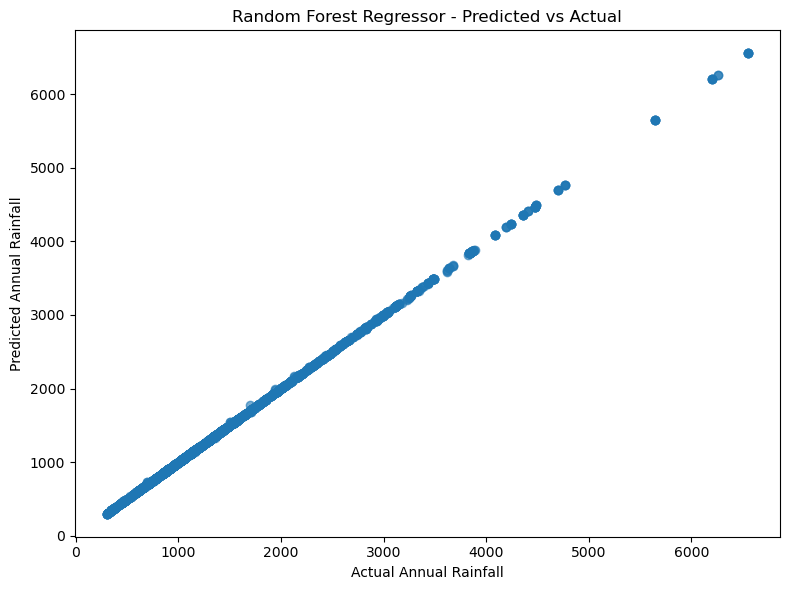

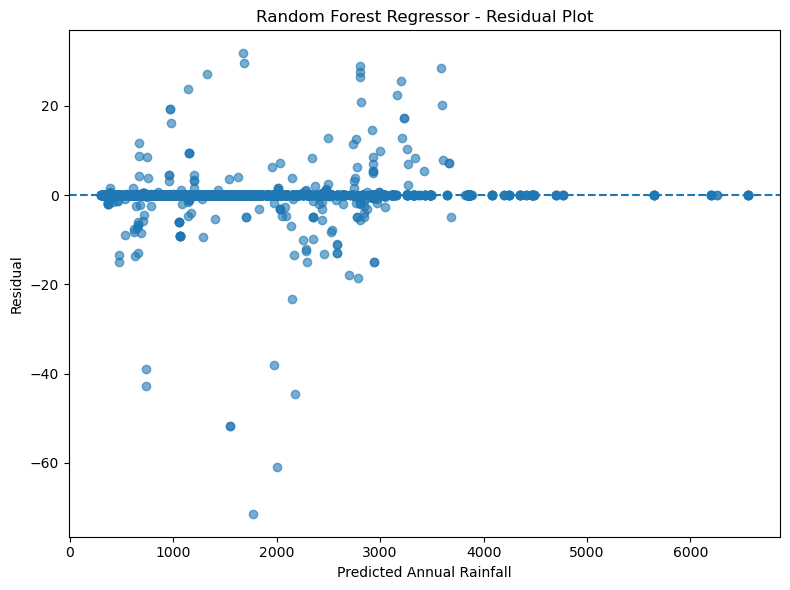

In [17]:
best_regression_name = regression_results_df.iloc[0]["Model"]
best_reg_predictions = regression_predictions[best_regression_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, best_reg_predictions, alpha=0.6)
plt.xlabel("Actual Annual Rainfall")
plt.ylabel("Predicted Annual Rainfall")
plt.title(f"{best_regression_name} - Predicted vs Actual")
plt.tight_layout()
plt.show()

residuals = y_test_reg - best_reg_predictions
plt.figure(figsize=(8, 6))
plt.scatter(best_reg_predictions, residuals, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Annual Rainfall")
plt.ylabel("Residual")
plt.title(f"{best_regression_name} - Residual Plot")
plt.tight_layout()
plt.show()


**Random Forest Regressor: Predicted vs Actual:**
The predicted values are closely aligned with the actual annual rainfall values, with most points lying almost exactly along the diagonal relationship. This indicates that the Random Forest Regressor achieves very high prediction accuracy on the test data, with only a few deviations at higher rainfall values.

**Random Forest Regressor: Residual Plot:**
Most residuals are concentrated around the zero line, indicating that the prediction errors are generally small. A few observations show larger positive or negative residuals, representing relatively higher prediction errors or possible extreme observations.

**Display Dataset 2**

In [18]:
DATA_FILE_2

,record_id,plant_type,habitat,season,air_humidity_pct,soil_humidity_pct,ethylene_ppm,co2_ppm,o2_ppm,ldr_on_plant,leaf_color_index,temperature_c,health_score,health_class
0,php_00001,rose,garden,winter,86.3,55.9,1.145,725.9,19.62,559,42.5,34.1,60,moderate_stress
1,php_00002,pothos,indoor,spring,55.3,29.8,1.102,1202.2,19.11,58,51.6,37.5,52,high_stress
2,php_00003,lettuce,greenhouse,autumn,92.6,10.3,1.042,1003.2,18.31,682,74.4,8.7,35,high_stress
3,php_00004,pothos,shade_house,autumn,62.0,40.3,0.700,566.3,20.43,460,57.7,29.8,92,healthy
4,php_00005,mint,indoor,spring,70.9,64.6,0.603,381.8,18.85,964,26.2,31.1,52,high_stress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,php_01996,lettuce,hydroponic,summer,27.5,86.5,1.906,684.1,20.25,69,88.7,35.4,37,high_stress
1996,php_01997,mint,greenhouse,spring,83.7,49.6,0.040,846.2,18.26,629,42.7,34.3,53,high_stress
1997,php_01998,rose,garden,monsoon,87.3,51.2,1.693,1198.2,19.46,96,25.1,33.8,28,high_stress
1998,php_01999,rose,garden,spring,73.5,60.3,2.305,699.1,18.75,547,93.5,25.4,69,moderate_stress


**Define Features and target**

In [19]:
# Target column
target_col_cls = "health_class"

# Remove ID and health_score
# health_score is removed to avoid target leakage
drop_columns_cls = [
    "record_id",
    "health_score"
]

# Features
X_cls = DATA_FILE_2.drop(
    columns=[target_col_cls] + drop_columns_cls
)

# Target
y_cls = DATA_FILE_2[target_col_cls]

print("Classification Features:")
print(X_cls.columns.tolist())

print("\nTarget Column:")
print(target_col_cls)

print("\nTarget Distribution:")
print(y_cls.value_counts())

Classification Features:
['plant_type', 'habitat', 'season', 'air_humidity_pct', 'soil_humidity_pct', 'ethylene_ppm', 'co2_ppm', 'o2_ppm', 'ldr_on_plant', 'leaf_color_index', 'temperature_c']

Target Column:
health_class

Target Distribution:
health_class
moderate_stress    929
high_stress        831
healthy            240
Name: count, dtype: int64


**Dataset 2 audit for Classification**

In [20]:
print(DATA_FILE_2.info())
print("\nMissing values:")
print(DATA_FILE_2.isnull().sum())
print("\nDuplicate rows:", DATA_FILE_2.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   record_id          2000 non-null   object 
 1   plant_type         2000 non-null   object 
 2   habitat            2000 non-null   object 
 3   season             2000 non-null   object 
 4   air_humidity_pct   2000 non-null   float64
 5   soil_humidity_pct  2000 non-null   float64
 6   ethylene_ppm       2000 non-null   float64
 7   co2_ppm            2000 non-null   float64
 8   o2_ppm             2000 non-null   float64
 9   ldr_on_plant       2000 non-null   int64  
 10  leaf_color_index   2000 non-null   float64
 11  temperature_c      2000 non-null   float64
 12  health_score       2000 non-null   int64  
 13  health_class       2000 non-null   object 
dtypes: float64(7), int64(2), object(5)
memory usage: 218.9+ KB
None

Missing values:
record_id            0
plant_type      

**Train and Test split**

In [21]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("Training samples:", X_train_cls.shape[0])
print("Testing samples:", X_test_cls.shape[0])

Training samples: 1600
Testing samples: 400


**Dataset 2 EDA for Classification preprocessing**

In [22]:
numeric_features_cls = X_cls.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features
categorical_features_cls = X_cls.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features_cls)

print("\nCategorical Features:")
print(categorical_features_cls)


# Numerical preprocessing
numeric_transformer_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_transformer_cls = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Combine both
preprocessor_cls = ColumnTransformer([
    ("num", numeric_transformer_cls, numeric_features_cls),
    ("cat", categorical_transformer_cls, categorical_features_cls)
])


Numerical Features:
['air_humidity_pct', 'soil_humidity_pct', 'ethylene_ppm', 'co2_ppm', 'o2_ppm', 'ldr_on_plant', 'leaf_color_index', 'temperature_c']

Categorical Features:
['plant_type', 'habitat', 'season']


**Train the 5  Classification algorithms**

In [23]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "KNN Classification": KNeighborsClassifier(
        n_neighbors=5
    ),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        C=1.0,
        kernel="rbf",
        random_state=RANDOM_STATE
    )
}
classification_results = []
classification_predictions = {}
classification_pipelines = {}
for name, model in classification_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor_cls),
        ("model", model)
    ])
    # Train model
    pipeline.fit(
        X_train_cls,
        y_train_cls
    )
    # Make predictions
    predictions = pipeline.predict(
        X_test_cls
    )
    # Calculate metrics
    accuracy = accuracy_score(
        y_test_cls,
        predictions
    )
    precision = precision_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test_cls,
        predictions,
        average="weighted",
        zero_division=0
    )
    # Store results
    classification_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])
    classification_predictions[name] = predictions
    classification_pipelines[name] = pipeline

**Classification comparison table**

In [24]:
classification_results_df = pd.DataFrame(
    classification_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)
classification_results_df = classification_results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

display(classification_results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.7775,0.784912,0.7775,0.772181
1,Decision Tree Classifier,0.6325,0.642976,0.6325,0.633007
2,KNN Classification,0.6175,0.635871,0.6175,0.619336
3,Gaussian Naive Bayes,0.6025,0.606677,0.6025,0.597398
4,Logistic Regression,0.6000,0.599546,0.6000,0.591088


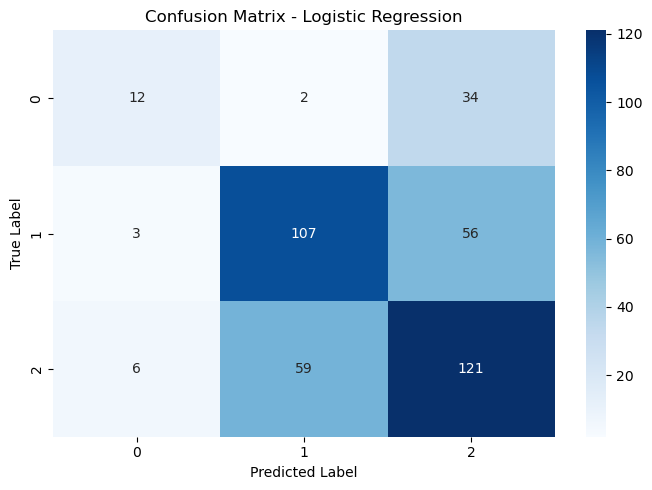

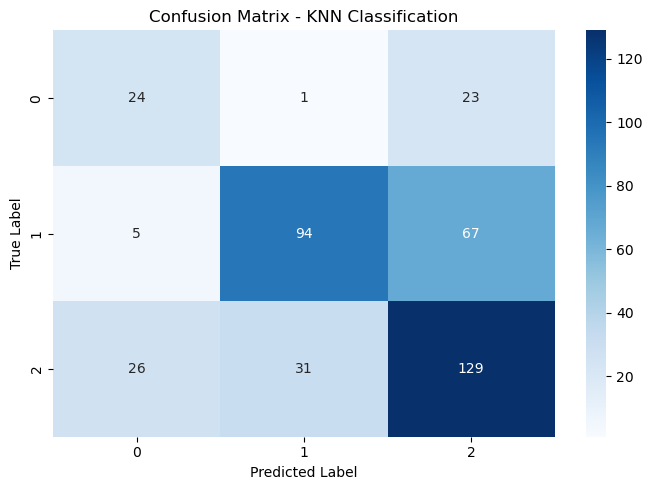

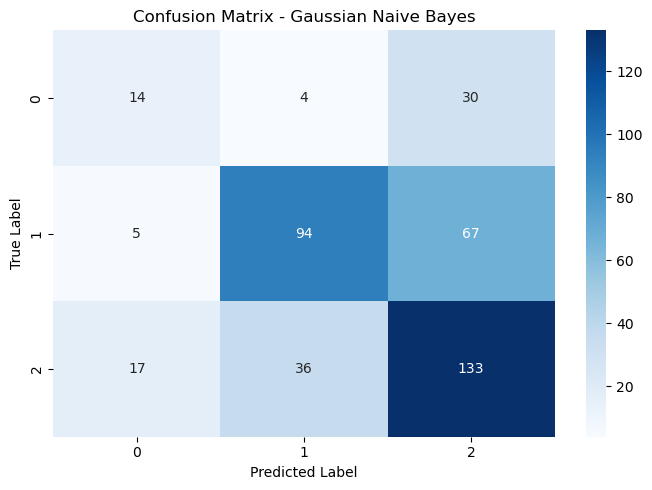

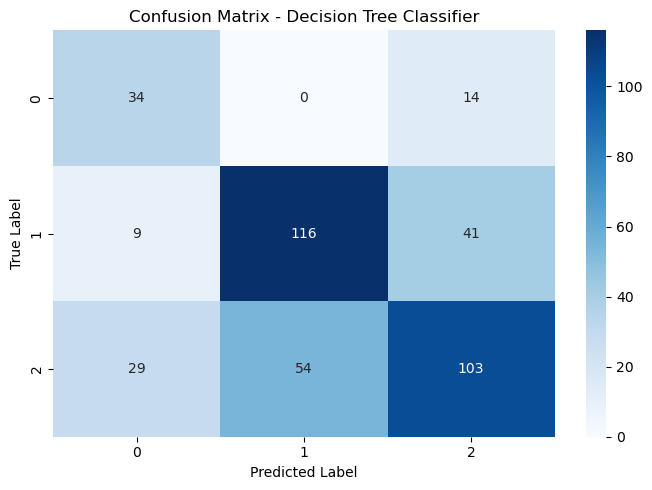

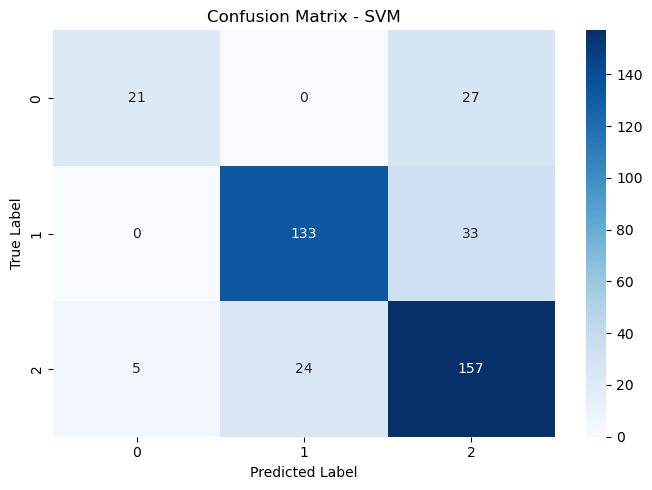

In [25]:
for name, predictions in classification_predictions.items():
    cm = confusion_matrix(
        y_test_cls,
        predictions
    )
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()